# Analyze and plot the results of T-maze simulation

### Import

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
import pandas as pd


In [2]:
scenario = "Tmaze"
trial_number = 10
use_example = False
save_plot = False

In [3]:
base_path = os.path.sep.join(os.path.abspath("__file__").split(os.path.sep)[:-2])
data_path = os.path.join(base_path,"data",scenario)
plot_path = os.path.join(base_path,"results",scenario,"plots")
folder_root = "trial"

sys.path.insert(0, os.path.join(base_path,"code/functions"))
os.makedirs(plot_path, exist_ok=True)

target_seed = np.arange(trial_number)

# Add the directory to sys.path
ref_path = os.path.join(data_path,folder_root+str(target_seed[0]))
sys.path.append(ref_path)

from global_variables import *
from Tmaze_variables import *
from Tmaze_functions import *
from plots import *
from stat_functions import *

# Fig. 4, Online learning

### Fig 4c, Plot averaged weights

In [4]:
load_lap = 10

CA3_weights = np.zeros((num_CA3_neurons,num_CA3_neurons,len(target_seed)))
CA1_weights = np.zeros((num_CA1_neurons,num_CA3_neurons,len(target_seed)))

CA3_place_fields = load_PF_starts("/data/suheecho/BTSP/data/Tmaze/PF_peak_data.pkl")

for ii,seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    
    ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(load_lap)))
    CA3_weights[:,:,ii] = ff["w_CA3_CA3"]; CA1_temp = ff["w_CA3_CA1"]
    del ff

    CA1_place_fields = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_%d.pkl"%(load_lap)))
    place_field_sorted_idx = np.array(list(CA1_place_fields.keys()))
    place_cue_mix_idx = np.zeros(num_CA1_neurons)
    pp_idx = np.sort(np.random.choice(num_CA1_neurons, len(place_field_sorted_idx), replace=False))
    place_cue_mix_idx[pp_idx] = place_field_sorted_idx
    cue_cell_idx = np.setdiff1d(np.arange(num_CA1_neurons),place_field_sorted_idx)
    place_cue_mix_idx[np.setdiff1d(np.arange(num_CA1_neurons),pp_idx)] = cue_cell_idx
    place_cue_mix_idx = place_cue_mix_idx.astype(np.int32)
    del pp_idx

    CA1_weights[:,:,ii] = CA1_temp[:,place_cue_mix_idx]


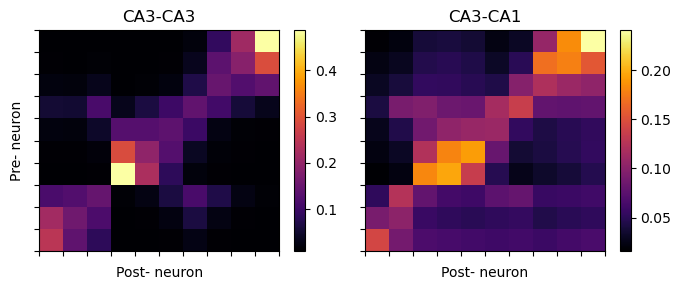

In [5]:
pop_per_unit = 1
n_pops = num_state_total * pop_per_unit
CA3_mean_wmx_arr = np.zeros((n_pops,n_pops,len(target_seed)))
CA1_mean_wmx_arr = np.zeros((n_pops,n_pops,len(target_seed)))
for seed in range(len(target_seed)):
    CA3_mean_wmx_arr[:,:,seed] = average_weight(CA3_weights[:,:,seed], n_pops, n_pops)
    CA1_mean_wmx_arr[:,:,seed] = average_weight(CA1_weights[:,:,seed], n_pops, n_pops)

CA3_mean_wmx = CA3_mean_wmx_arr.mean(-1)
CA1_mean_wmx = CA1_mean_wmx_arr.mean(-1)

fig, axs = plt.subplots(1,2,figsize=(7, 3)); plt.xlabel("Post- neuron")
fig, axs[0] = plot_heatmap(CA3_mean_wmx, fig=fig, ax=axs[0], title="CA3-CA3")
axs[0].set_xticks(np.linspace(0,n_pops,num_state_total+1)); axs[0].set_xticklabels([])
axs[0].set_yticks(np.linspace(0,n_pops,num_state_total+1)); axs[0].set_yticklabels([])
axs[0].set_ylabel("Pre- neuron"); axs[0].set_xlabel("Post- neuron")

fig, axs[1] = plot_heatmap(CA1_mean_wmx, fig=fig, ax=axs[1], title="CA3-CA1")
axs[1].set_xticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_xticklabels([])
axs[1].set_yticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_yticklabels([])
axs[1].set_xlabel("Post- neuron")

plt.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"avg_hippocampal_weights_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig. 4d, Predicted presence of two distinct rewards at each state

In [6]:
target_lap = [2,4,6,7,8,9,10]
foldername = folder_root + str(target_seed[0])
unit_gran = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_2.npz"))["unit_gran"]

W_feat_arr = np.zeros((len(target_seed),len(target_lap),num_CA1_neurons,num_features))
feat_pred_state = np.zeros((len(target_seed),len(target_lap),num_state_total,num_features))

for mm, seed in enumerate(target_seed):
    foldername = folder_root+str(seed)
    for ee, load_lap in enumerate(target_lap):
        w_CA1_feat=np.load(os.path.join(data_path,foldername,"lap_%d.npz"%load_lap))["w_CA1_feat"]
        CA1_activity = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_%d.npz"%load_lap))["CA1_activity"]
        CA1_PF = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_%d.pkl"%load_lap))

        place_field_sorted_idx = np.array(list(CA1_PF.keys()))
        place_cue_div_idx = np.hstack((place_field_sorted_idx,np.setdiff1d(np.arange(num_CA1_neurons),place_field_sorted_idx)))
        place_cue_mix_idx = np.zeros(num_CA1_neurons)
        pp_idx = np.sort(np.random.choice(num_CA1_neurons, len(place_field_sorted_idx), replace=False))
        place_cue_mix_idx[pp_idx] = place_field_sorted_idx
        cue_cell_idx = np.setdiff1d(np.arange(num_CA1_neurons),place_field_sorted_idx)
        place_cue_mix_idx[np.setdiff1d(np.arange(num_CA1_neurons),pp_idx)] = cue_cell_idx
        place_cue_mix_idx = place_cue_mix_idx.astype(np.int32)
        
        W_feat_arr[mm,ee,:,:] = w_CA1_feat[place_cue_mix_idx,:]
        feat_pred_arr = CA1_activity@w_CA1_feat

        for ss in range(num_state_total):
            feat_pred_state[mm,ee,ss] = np.max(np.squeeze(feat_pred_arr[ss*unit_gran+1:(ss+1)*unit_gran-1]),axis=0)

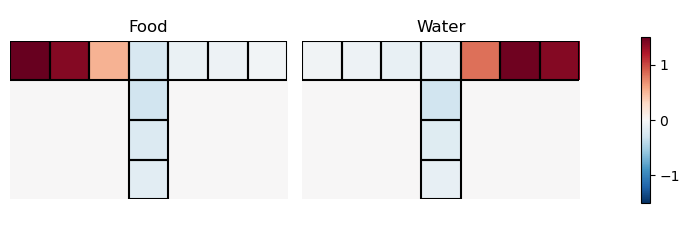

In [7]:
RW_pred_state = np.zeros((len(target_seed),num_state_total,2))
RW_pred_state[:,:,0] = np.squeeze(feat_pred_state[:,-2,:,0]); RW_pred_state[:,:,1] = np.squeeze(feat_pred_state[:,-1,:,1])

fig,axs = plt.subplots(1,3,width_ratios=[5,5,1],figsize=(7, 2.5))
plot_Tmaze_heat(RW_pred_state.mean(0)[:,0],axs[0]); axs[0].set_title("Food")
im = plot_Tmaze_heat(RW_pred_state.mean(0)[:,1],axs[1]); axs[1].set_title("Water")

axs[2].set_xticks([]); axs[2].set_yticks([])
for spine in ['top', 'right', 'bottom', 'left']:
    axs[2].spines[spine].set_visible(False)

fig.colorbar(im, ax=axs[2])

plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Reward_unit_activity.png"), dpi=300)
plt.show()

### Fig. 4g, Markov transition matrices based on motivational state

In [232]:
total_time = 50
possible_actions = np.array([[0,0],[0,-1],[0,1],[-1,0],[1,0]])  # left, stay, right
max_MI = 10; num_MI_scenario = max_MI+2
value_vector = np.ones((num_MI_scenario,2))

for MI in range(max_MI-1):
    value_vector[MI+1,0] = MI+2
value_vector[max_MI,1] = max_MI/2
value_vector[-1,0] = max_MI//2; value_vector[-1,1] = 0

value_arr = np.zeros((len(target_seed),num_MI_scenario,num_state_total))
for ii in range(len(target_seed)):
    for vv in range(num_MI_scenario):
        norm_pred = pred_norm(RW_pred_state[ii,:,:])
        value_arr[ii,vv,:] = norm_pred@value_vector[vv,:]
transition_matrix = np.zeros((len(target_seed), num_MI_scenario, num_state_total, num_state_total))

for mm in range(len(target_seed)):
    for vv in range(num_MI_scenario):
        transition_matrix[mm,vv,:,:], _ = compute_transition_matrix(num_state_total,value_arr[mm,vv],possible_actions,end_state=[3,9],softmax_coeff=0.5)

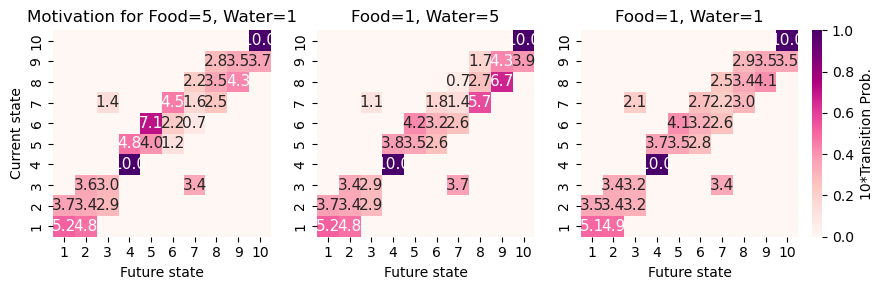

In [233]:
fig, axs = plt.subplots(1,3,width_ratios=(4,4,5),figsize=(9,3))
annot_data = create_annot_nonzero(10*transition_matrix.mean(0)[4])
sns.heatmap(transition_matrix.mean(0)[4], annot=annot_data, fmt='', annot_kws={"size":11},cmap="RdPu",ax=axs[0],cbar=False)
axs[0].set_xticklabels(np.arange(1,num_state_total+1)); axs[0].set_yticklabels(np.arange(1,num_state_total+1))
axs[0].invert_yaxis(); axs[0].set_ylabel("Current state"); axs[0].set_xlabel("Future state")
axs[0].set_title("Motivation for Food=5, Water=1")

annot_data = create_annot_nonzero(10*transition_matrix.mean(0)[-2])
sns.heatmap(transition_matrix.mean(0)[-2], annot=annot_data, fmt='', annot_kws={"size":11},cmap="RdPu",ax=axs[1],cbar=False)
axs[1].set_xticklabels(np.arange(1,num_state_total+1)); axs[1].set_yticklabels(np.arange(1,num_state_total+1))
axs[1].invert_yaxis(); axs[1].set_xlabel("Future state")
axs[1].set_title("Food=1, Water=5")

annot_data = create_annot_nonzero(10*transition_matrix.mean(0)[0])
sns.heatmap(transition_matrix.mean(0)[0], annot=annot_data, fmt='', annot_kws={"size":11},cmap="RdPu",ax=axs[2], cbar_kws={'label': '10*Transition Prob.'})
axs[2].set_xticklabels(np.arange(1,num_state_total+1)); axs[2].set_yticklabels(np.arange(1,num_state_total+1))
axs[2].invert_yaxis(); axs[2].set_xlabel("Future state")
axs[2].set_title("Food=1, Water=1")

fig.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Transition_matrix.png"), dpi=300)
plt.show()

### Fig. 4g, Choice-point asymmetry: P(left) − P(right) at state 7

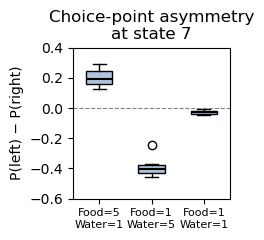

One-sample t-tests vs 0 (asymmetry ≠ 0):
  Food=5, Water=1: p=1.602e-06, p_fdr=2.402e-06, d=3.481, 95% CI [0.1616, 0.2453]
  Food=1, Water=5: p=6.855e-09, p_fdr=2.056e-08, d=-6.529, 95% CI [-0.4364, -0.3502]
  Food=1, Water=1: p=0.0001659, p_fdr=0.0001659, d=-1.949, 95% CI [-0.0376, -0.0174]

Paired t-tests between conditions:
  [Food=5, Water=1] vs [Food=1, Water=5]: p=5.487e-10, p_fdr=1.646e-09, d=8.680, 95% CI [0.5476, 0.6460]
  [Food=5, Water=1] vs [Food=1, Water=1]: p=9.386e-08, p_fdr=9.386e-08, d=4.845, 95% CI [0.1969, 0.2651]
  [Food=1, Water=5] vs [Food=1, Water=1]: p=2.27e-09, p_fdr=3.405e-09, d=-7.398, 95% CI [-0.4012, -0.3304]


In [234]:
# Choice point: state 6 (0-indexed), junction at position [0.5, 3.5]
# Left neighbor: state 5 (col 2.5, toward food arm at state 3)
# Right neighbor: state 7 (col 4.5, toward water arm at state 9)
choice_state = 6
left_state  = 5   # toward food (state 3)
right_state = 7   # toward water (state 9)

cond_vv     = [4, -2, 0]
cond_labels = ['Food=5\nWater=1', 'Food=1\nWater=5', 'Food=1\nWater=1']

# asymmetry[seed, condition] = P(left) - P(right)
asymmetry = np.zeros((len(target_seed), len(cond_vv)))
for ci, vv in enumerate(cond_vv):
    asymmetry[:, ci] = (transition_matrix[:, vv, choice_state, left_state]
                        - transition_matrix[:, vv, choice_state, right_state])

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
positions = np.arange(len(cond_vv))
bp = ax.boxplot([asymmetry[:, ci] for ci in range(len(cond_vv))],
                positions=positions, widths=0.5, patch_artist=True,
                medianprops=dict(color='k', linewidth=1.5),
                boxprops=dict(facecolor='lightsteelblue'))
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks(positions)
ax.set_xticklabels(cond_labels, fontsize=8)
ax.set_ylim([-0.6,0.4])
ax.set_ylabel('P(left) − P(right)')
ax.set_title('Choice-point asymmetry\nat state 7')
fig.tight_layout()
if save_plot:
    plt.savefig(os.path.join(plot_path, 'choice_point_asymmetry.png'), dpi=300)
plt.show()

# --- Statistics ---
# One-sample t-tests vs 0 per condition
p_1samp = []
for ci, label in enumerate(cond_labels):
    _, p = stats.ttest_1samp(asymmetry[:, ci], 0)
    p_1samp.append(p)
_, p_1samp_fdr, _, _ = multipletests(p_1samp, method='fdr_bh')

print("One-sample t-tests vs 0 (asymmetry ≠ 0):")
for ci, label in enumerate(cond_labels):
    d  = cohens_d_1samp(asymmetry[:, ci], 0)
    ci_lo, ci_hi = ci_1samp(asymmetry[:, ci])
    lbl = label.replace('\n', ', ')
    print(f"  {lbl}: p={p_1samp[ci]:.4g}, p_fdr={p_1samp_fdr[ci]:.4g}, "
          f"d={d:.3f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")

# Paired t-tests between conditions (3 pairs)
pair_indices = [(0, 1), (0, 2), (1, 2)]
p_pairs = []
for i, j in pair_indices:
    _, p = stats.ttest_rel(asymmetry[:, i], asymmetry[:, j])
    p_pairs.append(p)
_, p_pairs_fdr, _, _ = multipletests(p_pairs, method='fdr_bh')

print("\nPaired t-tests between conditions:")
for (i, j), p, pq in zip(pair_indices, p_pairs, p_pairs_fdr):
    d  = cohens_d_paired(asymmetry[:, i], asymmetry[:, j])
    ci_lo, ci_hi = ci_paired(asymmetry[:, i], asymmetry[:, j])
    li = cond_labels[i].replace('\n', ', ')
    lj = cond_labels[j].replace('\n', ', ')
    print(f"  [{li}] vs [{lj}]: p={p:.4g}, p_fdr={pq:.4g}, "
          f"d={d:.3f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")

### Fig. 4i, Final destination based on different motivational state

In [235]:
init_seed = 135

trajectory_arr = np.zeros((num_MI_scenario,len(target_seed),num_behav_trial,total_time))
goal_time_arr = np.zeros((num_MI_scenario,len(target_seed),num_behav_trial))
goal_state_arr = np.zeros(goal_time_arr.shape)
goal_count = np.zeros((num_MI_scenario,3,len(target_seed)))

for mm in range(len(target_seed)):
    for tt in range(num_behav_trial):
        for vv in range(num_MI_scenario):
            trajectory_arr[vv,mm,tt,:],goal_time_arr[vv,mm,tt],goal_state_arr[vv,mm,tt] = behavior_markov(transition_matrix[mm,vv,:,:], total_time=total_time, start_state=0, end_state=[3,9], seed=init_seed+mm*100+tt*10+vv)
            
            if goal_state_arr[vv,mm,tt] == 3: goal_count[vv,0,mm] += 1; continue
            elif goal_state_arr[vv,mm,tt] == 9: goal_count[vv,1,mm] += 1; continue
            else: goal_count[vv,2,mm] += 1

goalTime_mean = np.zeros(num_MI_scenario-2); goalTime_std = np.zeros(num_MI_scenario-2)
for vv in range(num_MI_scenario-2):
    goal_time_data = goal_time_arr[vv,:,:].reshape(-1)

    valid_idx = np.where(~np.isnan(goal_time_data))[0]
    goal_time_data = goal_time_data[valid_idx]
    goalTime_mean[vv] = goal_time_data.mean()
    goalTime_std[vv] = goal_time_data.std()/np.sqrt(num_behav_trial)


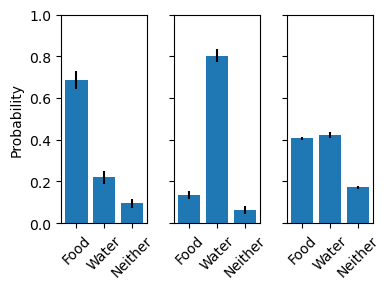


Paired t-tests comparing Food vs. water:
  [hungry]: p=8.216e-09, p_fdr=1.232e-08, d=6.397, 95% CI [0.4144, 0.5188]
  [thirsty]: p=9.688e-12, p_fdr=2.907e-11, d=-13.635, 95% CI [-0.7030, -0.6330]
  [neutral]: p=0.04059, p_fdr=0.04059, d=-0.756, 95% CI [-0.0296, -0.0008]


In [168]:
cases = cond_vv; label = ["hungry", "thirsty", "neutral"]

fig,axs = plt.subplots(1,3,figsize=(4,3))

for ii,vv in enumerate(cases):
    axs[ii].bar(np.arange(3),goal_count[vv].mean(-1)/num_behav_trial,yerr=goal_count[vv].std(-1)/(num_behav_trial)); axs[ii].set_ylim([0,1])
    axs[ii].set_xticks(np.arange(3)); axs[ii].set_xticklabels(["Food","Water","Neither"]); axs[ii].tick_params(axis='x', labelrotation=45)
    if ii>0: axs[ii].set_yticklabels([])
axs[0].set_ylabel("Probability")

fig.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"final_destination.png"), dpi=300)
plt.show()

p_pairs = []
for case in cases:
    _, p = stats.ttest_rel(goal_count[case,0]/num_behav_trial, goal_count[case,1]/num_behav_trial)
    p_pairs.append(p)
_, p_pairs_fdr, _, _ = multipletests(p_pairs, method='fdr_bh')

print("\nPaired t-tests comparing Food vs. water:")
for case, p, pq in zip(cases, p_pairs, p_pairs_fdr):
    d  = cohens_d_paired(goal_count[case,0]/num_behav_trial, goal_count[case,1]/num_behav_trial)
    ci_lo, ci_hi = ci_paired(goal_count[case,0]/num_behav_trial, goal_count[case,1]/num_behav_trial)
    print(f"  [{label[cases.index(case)]}]: p={p:.4g}, p_fdr={pq:.4g}, "
          f"d={d:.3f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")

### Fig. 4j, time taken to find food reward based on the motivational state

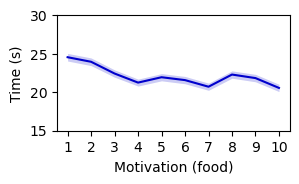

Mann_Kendall_Test(trend='decreasing', h=True, p=0.020044668622627437, z=-2.3255106965997814, Tau=-0.6, s=-27.0, var_s=125.0, slope=-0.3215603466144711, intercept=23.33821812206493)

In [170]:
fig, ax = plt.subplots(1,1,figsize=(3,1.5))
xx = np.arange(num_MI_scenario-2)
ax = plot_shaded(xx+1,goalTime_mean,goalTime_std,ax,color=[0,0,0.8])
ax.set_xticks(xx+1); ax.set_ylim([15,total_time-20])
ax.set_xlabel("Motivation (food)"); ax.set_ylabel("Time (s)")

if save_plot: plt.savefig(os.path.join(plot_path,"Goal_reach_time.png"), dpi=300)
plt.show()

import pymannkendall as mk
result = mk.original_test(goalTime_mean)
result

# Fig. 5, The impact offline learning based on replay type

### Fig 5b, Spontaneously generated on-site offline activity

In [173]:
import pickle

load_lap = 10; pause_state = 4
replay_time = []

for trial in range(trial_number):
    foldername = folder_root+str(trial)
    trial_list = []
    for replay_type in range(len(replay_trajectory)):
        type_list = []
        fname = os.path.join(data_path,foldername,'replay_type_%d.pkl'%replay_type)
        with open(fname, 'rb') as fp: replays = pickle.load(fp)
        for tt in replays.keys(): type_list.append(list(tt))
        trial_list.append(type_list)
    replay_time.append(trial_list)

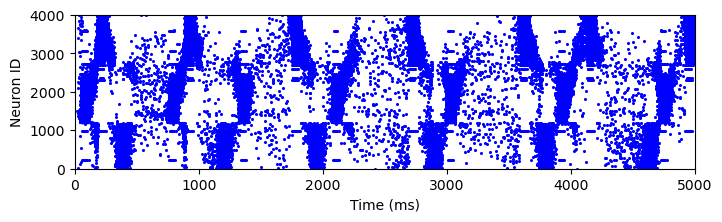

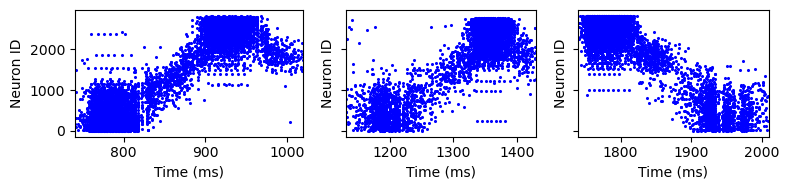

In [174]:
example_trial_idx = 3

CA3_PF = load_PF_starts()
CA3_place_cell_ID_list = generate_place_cell_ID_list(np.array(list(CA3_PF.keys()),dtype=int), np.array(list(CA3_PF.values())))
ff = np.load(os.path.join(data_path,folder_root+str(target_seed[example_trial_idx]),"CA3_replay_lap_%d_pause_%d.npz"%(load_lap, pause_state)))
spike_times_CA3 = ff['spike_times_CA3_PC']; spiking_neurons_CA3 = ff['spiking_neurons_CA3_PC']; rate_CA3 = ff['rate_CA3_PC']
del ff

fig,ax = plt.subplots(1,1,figsize=(8,2))

target_idx = reorder_neuron_idx(CA3_place_cell_ID_list,CA3_PF,np.arange(num_state_total))
plot_spike(spike_times_CA3, spiking_neurons_CA3, target_idx,
               zoom_from=0, zoom_to=rest_time, ax=ax)
ax.set_ylim([0, num_CA3_neurons])

fig,axs = plt.subplots(1,3,figsize=(8,2), width_ratios=[1.2,1,1], sharey=True)

for rep_type, rep_traj in enumerate(replay_trajectory):
    time_window = replay_time[example_trial_idx][rep_type][0]
    target_idx = reorder_neuron_idx(CA3_place_cell_ID_list,CA3_PF,rep_traj)
    plot_spike(spike_times_CA3, spiking_neurons_CA3, target_idx,
                zoom_from=time_window[0], zoom_to=time_window[1], ax=axs[rep_type])
    # axs[rep_type].set_ylim([0, len(target_idx)]); axs[rep_type].set_ylabel("")

fig.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Onsite_replay_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig. 5d, Food prediction updated induced by different types of replay events

In [175]:
RW_pred_before = list(); RW_pred_after = list()
    
for rep_type in range(len(replay_trajectory)):
    for mm, trial in enumerate(range(trial_number)):
        foldername = folder_root + str(trial)
        replays_trial = replay_time[trial][rep_type]
        w_CA1_feat = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%load_lap))["w_CA1_feat"]
        
        before = np.zeros((len(replays_trial),num_state_total)); after = np.zeros_like(before)

        for rr, replay in enumerate(replays_trial):
            bf_time = replay[0]; af_time = replay[1]
            bf_act = np.load(os.path.join(data_path,foldername,"activity/CA1_activity_lap_%d_replay_%d.npz"%(load_lap,bf_time)))["CA1_activity"]
            af_act = np.load(os.path.join(data_path,foldername,"activity/CA1_activity_lap_%d_replay_%d.npz"%(load_lap,af_time)))["CA1_activity"]

            bf_temp = (bf_act@w_CA1_feat).T[0]; af_temp = (af_act@w_CA1_feat).T[0]

            for ss in range(num_state_total):
                before[rr,ss] = bf_temp[ss*unit_gran:(ss+1)*unit_gran].mean()
                after[rr,ss] = af_temp[ss*unit_gran:(ss+1)*unit_gran].mean()

        if mm == 0: before_type = before; after_type = after
        else: before_type = np.vstack((before_type, before)); after_type = np.vstack((after_type, after))
        del before, after

    RW_pred_before.append(before_type); RW_pred_after.append(after_type)
    del before_type, after_type

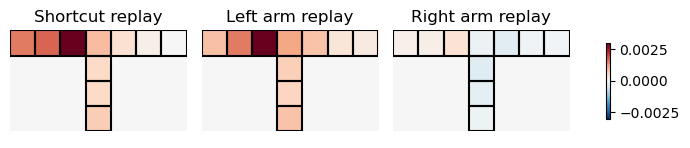

In [176]:
fig, axs = plt.subplots(1,4,width_ratios=[7,7,7,1],figsize=(7, 1.5))

for rr in range(len(replay_trajectory)):
    data = RW_pred_after[rr] - RW_pred_before[rr]
    im = plot_Tmaze_heat(data.mean(0),axs[rr],vmax=3e-3)

axs[0].set_title("Shortcut replay")
axs[1].set_title("Left arm replay")
axs[2].set_title("Right arm replay")

axs[3].set_xticks([]); axs[3].set_yticks([])
for spine in ['top', 'right', 'bottom', 'left']:
    axs[3].spines[spine].set_visible(False)

fig.colorbar(im, ax=axs[3])

plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Prediction_update_replay_types.png"), dpi=300)
plt.show()

### Fig. 5e, Food prediction update of replayed vs. non-replayed trajectory

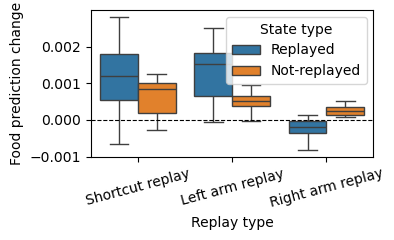

Shortcut replay: p=2.554e-08, FDR-corrected p=3.831e-08
Left arm replay: p=4.566e-06, FDR-corrected p=4.566e-06
Right arm replay: p=9.929e-13, FDR-corrected p=2.979e-12


In [177]:
replay_labels = ["Shortcut replay", "Left arm replay", "Right arm replay"]

predchange_df = pd.DataFrame(columns=['Replay type','State type','Pred. change'])
for rr in range(len(replay_trajectory)):
    replayed_states = replay_trajectory[rr]
    nonreplayed_states = [ss for ss in range(num_state_total) if ss not in replayed_states]

    data = RW_pred_after[rr] - RW_pred_before[rr]  # (num_events, num_state_total)
    replayed_change = data[:,replayed_states].mean(axis=1)
    nonreplayed_change = data[:,nonreplayed_states].mean(axis=1)

    for val in replayed_change: predchange_df.loc[len(predchange_df)] = [replay_labels[rr],'Replayed',val]
    for val in nonreplayed_change: predchange_df.loc[len(predchange_df)] = [replay_labels[rr],'Not-replayed',val]

fig, ax = plt.subplots(1,1,figsize=(4,2.5))
sns.boxplot(x='Replay type', y='Pred. change', hue='State type', data=predchange_df, ax=ax)
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_ylabel("Food prediction change")
plt.xticks(rotation=15)
plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Prediction_change_replayed_vs_nonreplayed.png"), dpi=300)
plt.show()

p_vals = []
for rr in range(len(replay_trajectory)):
    replayed_states = replay_trajectory[rr]
    nonreplayed_states = [ss for ss in range(num_state_total) if ss not in replayed_states]
    data = RW_pred_after[rr] - RW_pred_before[rr]
    replayed_change = data[:,replayed_states].mean(axis=1)
    nonreplayed_change = data[:,nonreplayed_states].mean(axis=1)
    _, p = stats.ttest_rel(replayed_change, nonreplayed_change)
    p_vals.append(p)

_, p_fdr, _, _ = multipletests(p_vals, method='fdr_bh')
for label, p, pq in zip(replay_labels, p_vals, p_fdr):
    print("%s: p=%.4g, FDR-corrected p=%.4g"%(label, p, pq))

### Fig. 5e, Food prediction updated induced by the entire offline activity

In [236]:
RW_pred_state_replay = np.zeros((len(target_seed),num_state_total))

for mm, seed in enumerate(target_seed):
    foldername = folder_root+str(seed)

    w_CA1_feat = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%load_lap))["w_CA1_feat"]
    activity_replay = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_%d_replay_5000.npz"%load_lap))["CA1_activity"]
    
    RW_pred_arr_replay = activity_replay@w_CA1_feat
    RW_pred_arr_replay = RW_pred_arr_replay[:,0]
    del w_CA1_feat, activity_replay
    
    for ss in range(num_state_total):
        RW_pred_state_replay[mm,ss] = np.max(np.squeeze(RW_pred_arr_replay[ss*unit_gran:(ss+1)*unit_gran]))
    del RW_pred_arr_replay

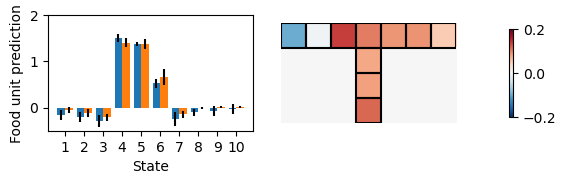

In [237]:
fig,axs = plt.subplots(1,3,width_ratios=[7,6,1],figsize=(6, 1.5))
category = np.arange(num_state_total)+1
bar_width = 0.4
axs[0].bar(category-bar_width/2,RW_pred_state.mean(0)[:,0].T,yerr=RW_pred_state.std(0)[:,0].T, capsize=0, width = bar_width)
axs[0].bar(category+bar_width/2,RW_pred_state_replay.mean(0),yerr=RW_pred_state_replay.std(0), capsize=0, width = bar_width)
axs[0].set_xticks(np.arange(num_state_total)+1); axs[0].set_ylim([-0.5,2])
axs[0].set_xlabel("State"); axs[0].set_ylabel("Food unit prediction")

data = RW_pred_state_replay.mean(0) - RW_pred_state.mean(0)[:,0]
im=plot_Tmaze_heat(data,axs[1],vmax=0.2)

axs[2].set_xticks([]); axs[2].set_yticks([])
for spine in ['top', 'right', 'bottom', 'left']:
    axs[2].spines[spine].set_visible(False)

fig.colorbar(im, ax=axs[2])

if save_plot: plt.savefig(os.path.join(plot_path,"Prediction_update_entire_offline.png"), dpi=300)
plt.show()

In [238]:
value_arr_replay = np.zeros((len(target_seed),num_state_total))
for ii in range(len(target_seed)):
    norm_pred = pred_norm(np.array(RW_pred_state_replay[ii]))
    value_arr_replay[ii] = norm_pred*5#value_vector[-1,0]

transition_matrix_replay = np.zeros((len(target_seed), num_state_total, num_state_total))
transition_matrix_newstart = np.zeros((len(target_seed), 2, num_state_total, num_state_total))

for mm in range(len(target_seed)):
    transition_matrix_replay[mm], _ = compute_transition_matrix(num_state_total,value_arr_replay[mm],possible_actions,end_state=[3,9],softmax_coeff=0.5)
    transition_matrix_newstart[mm,0], _ = compute_transition_matrix(num_state_total,value_arr[mm,-1,:],possible_actions,end_state=[0,3],softmax_coeff=0.5)
    transition_matrix_newstart[mm,1], _ = compute_transition_matrix(num_state_total,value_arr_replay[mm],possible_actions,end_state=[0,3],softmax_coeff=0.5)


In [239]:
# from collections import deque

# def bfs_distance(source_state):
#     dist = -np.ones(num_state_total, dtype=int)
#     dist[source_state] = 0
#     queue = deque([source_state])
#     while queue:
#         cur = queue.popleft()
#         for nxt in range(num_state_total):
#             if dist[nxt] == -1 and np.linalg.norm(state_position[cur]-state_position[nxt]) == 1:
#                 dist[nxt] = dist[cur]+1
#                 queue.append(nxt)
#     return dist

# reward_state = num_state_row  # state 4 (1-indexed), the food-reward location
# state_dist = bfs_distance(reward_state)
# unique_dist = np.unique(state_dist)

# before_data = RW_pred_state[:,:,0]   # before offline learning
# after_data = RW_pred_state_replay    # after offline learning

# before_mean = np.zeros(len(unique_dist)); before_sem = np.zeros(len(unique_dist))
# after_mean = np.zeros(len(unique_dist)); after_sem = np.zeros(len(unique_dist))

# for ii, dd in enumerate(unique_dist):
#     states_at_dist = np.where(state_dist == dd)[0]
#     vals_before = before_data[:,states_at_dist].flatten()
#     vals_after = after_data[:,states_at_dist].flatten()
#     before_mean[ii] = vals_before.mean(); before_sem[ii] = vals_before.std()/np.sqrt(len(vals_before))
#     after_mean[ii] = vals_after.mean(); after_sem[ii] = vals_after.std()/np.sqrt(len(vals_after))

# fig, ax = plt.subplots(1,1,figsize=(3,2.5))
# ax = plot_shaded(unique_dist, before_mean, before_sem, ax, color='black')
# ax = plot_shaded(unique_dist, after_mean, after_sem, ax, color='red')
# ax.set_xticks(unique_dist)
# ax.set_xlabel("Distance from reward (steps)"); ax.set_ylabel("Food unit prediction")

# if save_plot: plt.savefig(os.path.join(plot_path,"Prediction_vs_distance.png"), dpi=300)
# plt.show()

### Fig 5h. Choice point asymmetry in two different behavior scenarios

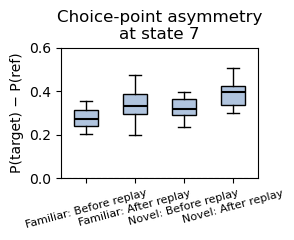


Paired t-tests between conditions:
  [Familiar: Before replay] vs [Familiar: After replay]: p=0.003, p_fdr=0.003, d=-1.272, 95% CI [-0.0932, -0.0261]
  [Novel: Before replay] vs [Novel: After replay]: p=0.0001366, p_fdr=0.0002733, d=-2.001, 95% CI [-0.0862, -0.0408]


In [351]:
# Choice point: state 6 (0-indexed), junction at position [0.5, 3.5]
choice_state = 6

cond_labels = ['Familiar: Before replay', 'Familiar: After replay', 'Novel: Before replay', 'Novel: After replay']

# asymmetry[seed, (before replay, after replay)] = P(target) - P(ref)
asymmetry = np.zeros((len(target_seed), len(cond_labels)))

# "Familiar" scenario
target_state  = 5   # toward food (state 3)
ref_state = 7   # away from food (state 8)

asymmetry[:,0] = (transition_matrix[:, -1, choice_state, target_state]
                        - transition_matrix[:, -1, choice_state, ref_state])
asymmetry[:,1] = (transition_matrix_replay[:, choice_state, target_state]
                        - transition_matrix_replay[:, choice_state, ref_state])

# "Novel" scenario
target_state  = 5   # toward food (state 3)
ref_state = 2   # away from food (state 8)

asymmetry[:,2] = (transition_matrix_newstart[:, 0, choice_state, target_state]
                        - transition_matrix_newstart[:, 0, choice_state, ref_state])
asymmetry[:,3] = (transition_matrix_newstart[:, 1, choice_state, target_state]
                        - transition_matrix_newstart[:, 1, choice_state, ref_state])

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))
positions = np.arange(len(cond_labels))
bp = ax.boxplot([asymmetry[:, ci] for ci in range(len(cond_labels))],
                positions=positions, widths=0.5, patch_artist=True,
                medianprops=dict(color='k', linewidth=1.5),
                boxprops=dict(facecolor='lightsteelblue'))
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks(positions)
ax.set_xticklabels(cond_labels, fontsize=8, rotation=15)
ax.set_ylim([0,0.6])
ax.set_ylabel('P(target) − P(ref)')
ax.set_title('Choice-point asymmetry\nat state 7')
fig.tight_layout()
if save_plot:
    plt.savefig(os.path.join(plot_path, 'choice_point_asymmetry_2scenarios.png'), dpi=300)
plt.show()

# Paired t-tests between conditions
pair_indices = [(0, 1), (2, 3)]
p_pairs = []
for i, j in pair_indices:
    _, p = stats.ttest_rel(asymmetry[:, i], asymmetry[:, j])
    p_pairs.append(p)
_, p_pairs_fdr, _, _ = multipletests(p_pairs, method='fdr_bh')

print("\nPaired t-tests between conditions:")
for (i, j), p, pq in zip(pair_indices, p_pairs, p_pairs_fdr):
    d  = cohens_d_paired(asymmetry[:, i], asymmetry[:, j])
    ci_lo, ci_hi = ci_paired(asymmetry[:, i], asymmetry[:, j])
    li = cond_labels[i].replace('\n', ', ')
    lj = cond_labels[j].replace('\n', ', ')
    print(f"  [{li}] vs [{lj}]: p={p:.4g}, p_fdr={pq:.4g}, "
          f"d={d:.3f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")

### Fig. 5j

In [339]:
trajectory_arr_replay = np.zeros((len(target_seed),num_behav_trial,total_time),dtype=int)
goal_time_arr_replay = np.zeros((len(target_seed),num_behav_trial))
goal_state_arr_replay = np.zeros(goal_time_arr_replay.shape)
goal_count_replay = np.zeros((3,len(target_seed)))

init_seed = 987
for mm in range(len(target_seed)):
    for tt in range(num_behav_trial):
        trajectory_arr_replay[mm,tt,:],goal_time_arr_replay[mm,tt],goal_state_arr_replay[mm,tt] = behavior_markov(transition_matrix_replay[mm], total_time=total_time, start_state=0, end_state=[3,9], seed=init_seed+mm*100+tt*10)
        if goal_state_arr_replay[mm,tt] == 3: goal_count_replay[0,mm] += 1; continue
        elif goal_state_arr_replay[mm,tt] == 9: goal_count_replay[1,mm] += 1; continue
        else: goal_count_replay[2,mm] += 1

In [ ]:
trajectory_arr_newstart = np.zeros((2,len(target_seed),num_behav_trial,total_time),dtype=int)
goal_time_arr_newstart = np.zeros((2,len(target_seed),num_behav_trial))
goal_state_arr_newstart = np.zeros(goal_time_arr_newstart.shape)
goal_count_newstart= np.zeros((2,3,len(target_seed)))

init_seed = 9876
for mm in range(len(target_seed)):
    for tt in range(num_behav_trial):
        for vv in range(2):
            trajectory_arr_newstart[vv,mm,tt,:],goal_time_arr_newstart[vv,mm,tt],goal_state_arr_newstart[vv,mm,tt] = behavior_markov(transition_matrix_newstart[mm,vv,:,:], total_time=total_time, start_state=9, end_state=[3,0], seed=init_seed+mm*100+tt*10)
            if goal_state_arr_newstart[vv,mm,tt] == 3: goal_count_newstart[vv,0,mm] += 1; continue
            elif goal_state_arr_newstart[vv,mm,tt] == 0: goal_count_newstart[vv,1,mm] += 1; continue
            else: goal_count_newstart[vv,2,mm] += 1

In [341]:
goalcnt_df = pd.DataFrame(columns=['Replay','Scenario','P(food)'])
for mm in target_seed:
    d = goal_time_arr_replay[mm]; d = d[~np.isnan(d)]
    goalcnt_df.loc[len(goalcnt_df)] = ['Before','Familiar',goal_count[-1,0,mm]/num_behav_trial]

    goalcnt_df.loc[len(goalcnt_df)] = ['After','Familiar',goal_count_replay[0,mm]/num_behav_trial]

    d = np.squeeze(goal_time_arr_newstart[1,mm]); d = d[~np.isnan(d)]
    goalcnt_df.loc[len(goalcnt_df)] = ['Before','Novel',goal_count_newstart[0,0,mm]/num_behav_trial]

    d = np.squeeze(goal_time_arr_newstart[0,mm]); d = d[~np.isnan(d)]
    goalcnt_df.loc[len(goalcnt_df)] = ['After','Novel',goal_count_newstart[1,0,mm]/num_behav_trial]


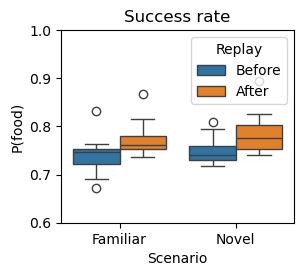

P(food) Familiar (before vs after): p=0.001956, p_fdr=0.003913, d=-1.364, 95% CI [-0.0534, -0.0166]
P(food) Novel    (before vs after): p=0.005292, p_fdr=0.005292, d=-1.155, 95% CI [-0.0580, -0.0136]


In [352]:
plt.figure(figsize=(3, 2.5))
sns.boxplot(x='Scenario', y='P(food)', hue='Replay', data=goalcnt_df)
plt.title('Success rate'); plt.ylim([0.6,1.0])
plt.show()

fam_bf = goalcnt_df[(goalcnt_df['Replay']=='Before')&(goalcnt_df['Scenario']=='Familiar')]['P(food)']
fam_af = goalcnt_df[(goalcnt_df['Replay']=='After') &(goalcnt_df['Scenario']=='Familiar')]['P(food)']
nov_bf = goalcnt_df[(goalcnt_df['Replay']=='Before')&(goalcnt_df['Scenario']=='Novel')]  ['P(food)']
nov_af = goalcnt_df[(goalcnt_df['Replay']=='After') &(goalcnt_df['Scenario']=='Novel')]  ['P(food)']

_, p_fam = stats.ttest_rel(fam_bf, fam_af)
_, p_nov = stats.ttest_rel(nov_bf, nov_af)
_, p_fdr, _, _ = multipletests([p_fam, p_nov], method='fdr_bh')

for label, x, y, p, pq in [
    ('Familiar (before vs after)', fam_bf, fam_af, p_fam, p_fdr[0]),
    ('Novel    (before vs after)', nov_bf, nov_af, p_nov, p_fdr[1]),
]:
    d = cohens_d_paired(x, y)
    ci_lo, ci_hi = ci_paired(x, y)
    print(f"P(food) {label}: p={p:.4g}, p_fdr={pq:.4g}, d={d:.3f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")


In [343]:
goaltime_df = pd.DataFrame(columns=['Replay','Scenario','Time (s)'])
for mm in target_seed:
    d = np.squeeze(goal_time_arr[-1,mm]); d = d[~np.isnan(d)]
    goaltime_df.loc[len(goaltime_df)] = ['Before','Familiar',d.mean()]

    d = goal_time_arr_replay[mm]; d = d[~np.isnan(d)]
    goaltime_df.loc[len(goaltime_df)] = ['After','Familiar',d.mean()]

    d = np.squeeze(goal_time_arr_newstart[0,mm]); d = d[~np.isnan(d)]
    goaltime_df.loc[len(goaltime_df)] = ['Before','Novel',d.mean()]

    d = np.squeeze(goal_time_arr_newstart[1,mm]); d = d[~np.isnan(d)]
    goaltime_df.loc[len(goaltime_df)] = ['After','Novel',d.mean()]


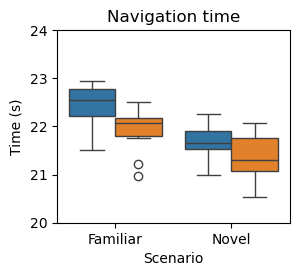

Time (s) Familiar (before vs after): p=0.004993, p_fdr=0.009986, d=1.167, 95% CI [0.1940, 0.8083]
Time (s) Novel    (before vs after): p=0.02144, p_fdr=0.02144, d=0.879, 95% CI [0.0567, 0.5528]


In [354]:
plt.figure(figsize=(3, 2.5))
sns.boxplot(x='Scenario', y='Time (s)', hue='Replay', data=goaltime_df, legend=False)
plt.title('Navigation time'); plt.ylim([20,24])
plt.show()

fam_bf = goaltime_df[(goaltime_df['Replay']=='Before')&(goaltime_df['Scenario']=='Familiar')]['Time (s)']
fam_af = goaltime_df[(goaltime_df['Replay']=='After') &(goaltime_df['Scenario']=='Familiar')]['Time (s)']
nov_bf = goaltime_df[(goaltime_df['Replay']=='Before')&(goaltime_df['Scenario']=='Novel')]  ['Time (s)']
nov_af = goaltime_df[(goaltime_df['Replay']=='After') &(goaltime_df['Scenario']=='Novel')]  ['Time (s)']

_, p_fam = stats.ttest_rel(fam_bf, fam_af)
_, p_nov = stats.ttest_rel(nov_bf, nov_af)
_, p_fdr, _, _ = multipletests([p_fam, p_nov], method='fdr_bh')

for label, x, y, p, pq in [
    ('Familiar (before vs after)', fam_bf, fam_af, p_fam, p_fdr[0]),
    ('Novel    (before vs after)', nov_bf, nov_af, p_nov, p_fdr[1]),
]:
    d = cohens_d_paired(x, y)
    ci_lo, ci_hi = ci_paired(x, y)
    print(f"Time (s) {label}: p={p:.4g}, p_fdr={pq:.4g}, d={d:.3f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")
